In [3]:
from langgraph.graph import END, StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain_ollama import ChatOllama
from langchain.messages import RemoveMessage

/home/narendra/Agentic AI/agentenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
load_dotenv()

True

In [5]:
model = ChatOllama(base_url="http://206.1.53.104:11434/", model="qwen2.5-coder:7b")

In [7]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [8]:
def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [9]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [10]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")  # run deletion after each response
builder.add_edge("cleanup", "__end__")

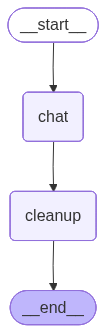

In [11]:
graph = builder.compile(checkpointer=InMemorySaver())
graph

In [12]:
config = {"configurable": {"thread_id": "t1"}}

In [13]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Nitish"}]}, config)
graph.invoke(
    {"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config
)
graph.invoke(
    {"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config
)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)

{'messages': [HumanMessage(content="Hi, I'm Nitish", additional_kwargs={}, response_metadata={}, id='cf7a8e08-ad94-4f1f-abdb-d0109893e069'),
  AIMessage(content='Hello Nitish! How can I assist you today?', additional_kwargs={}, response_metadata={'model': 'qwen2.5-coder:7b', 'created_at': '2026-03-29T16:36:40.931751966Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2968275168, 'load_duration': 2815903547, 'prompt_eval_count': 35, 'prompt_eval_duration': 22889600, 'eval_count': 12, 'eval_duration': 86997374, 'logprobs': None, 'model_name': 'qwen2.5-coder:7b', 'model_provider': 'ollama'}, id='lc_run--019d3a74-5d5a-7683-893d-d499dae903d4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 35, 'output_tokens': 12, 'total_tokens': 47}),
  HumanMessage(content='Tell me about LangGraph', additional_kwargs={}, response_metadata={}, id='edd0f2e2-f46e-4873-9a8e-502c7d95bb61'),
  AIMessage(content="LangGraph is not a widely known term or product. It could be possi

In [14]:
graph.invoke(
    {"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config
)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='a7354753-c97d-41d8-8ccf-5938f0b84e7c'),
  AIMessage(content="LangChain is a software platform that simplifies the creation of applications using natural language processing (NLP). It provides developers with tools and libraries to build intelligent chatbots, virtual assistants, and other NLP-based applications without requiring extensive expertise in machine learning.\n\nKey features of LangChain include:\n\n1. **Pre-trained Models**: Access to pre-trained models for various NLP tasks such as text classification, sentiment analysis, language translation, and more.\n2. **Custom Training**: Tools for fine-tuning these pre-trained models on specific datasets to improve performance for your application's needs.\n3. **Integration Capabilities**: Easy integration with other software systems and platforms to extend the functionality of your NLP applications.\n4. **Developer-friendly APIs**:

In [16]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8
